## Across trial variability DDM: training

DDM with drift rate, starting point, boundary, and non-decision time. 

The drift rate on trial $t$, $v_t$, is drawn from a normal distribution, centered around the overall drift rate $v$, with standard deviation $s_v$: 

$v_t$ ~ N($v$, $s_v$)

The starting point on each trial, $z_t$, comes from a uniform distribution, centered around the overall starting point $z$, with range $s_z$:

$z_t$ ~ U($z$-$s_z$/2, $z$+$s_z$/2, [0,1])

Drift rate is multiplied with stimulus (uniform between -1 or +1).

In [1]:
import numpy as np
import os
from numba import njit
import bayesflow as bf
import tensorflow as tf
from scipy.stats import uniform
import matplotlib.pyplot as plt
import seaborn as sns
import math
import pandas as pd

from numba import cuda
from numba.cuda.random import create_xoroshiro128p_states, xoroshiro128p_uniform_float32, xoroshiro128p_normal_float32

import logging
numba_logger = logging.getLogger('numba')
numba_logger.setLevel(logging.WARNING)
from tensorflow.python.platform import build_info as tf_build_info
print("cudnn_version",tf_build_info.build_info['cudnn_version'])
print("cuda_version",tf_build_info.build_info['cuda_version'])

2026-06-16 10:30:54.583584: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-16 10:30:54.607591: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-16 10:30:54.607622: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-16 10:30:54.608446: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-16 10:30:54.613152: I tensorflow/core/platform/cpu_feature_guar

2026-06-16 10:30:55.718891: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


cudnn_version 8
cuda_version 12.2


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/bayesflow/trainers.py:27: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
print(tf.config.list_physical_devices('GPU'))

2026-06-16 10:30:59.929334: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2348] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 10.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Create folder if it does not exist
os.makedirs("Figures", exist_ok=True)
os.makedirs("Data", exist_ok=True)

## Set priors

In [4]:
RNG = np.random.default_rng(0)

min_n_trials = 350
max_n_trials = 3250

batch_size = 32

"""
Set parameters for prior distributions
"""

v_lower, v_upper = 0.0, 5.0
z_lower, z_upper = -2.0, 2.0 # sigmoid transformation is used to keep z+z_bias between 0 and 1
a_lower, a_upper = 0.1, 5.0
ter_lower, ter_upper = 0.01, 1.0

sv_lower, sv_upper = 0.0, 2.5
sz_lower, sz_upper = 0.0, 2.5 # also before sigmoid transformation

## Prior functions

In [5]:
def sample_shared_parameters():
    """
    Drift rate, starting point, boundary, non-decision time
    """
    
    v = np.random.uniform(v_lower, v_upper) # drift rate
    z = np.random.uniform(z_lower, z_upper) # starting point (relative to boundary), before sigmoid transformation
    a = np.random.uniform(a_lower, a_upper) # boundary
    ter = np.random.uniform(ter_lower, ter_upper) # non-decision time
    
    sv = np.random.uniform(sv_lower, sv_upper) # boundary
    sz = np.random.uniform(sz_lower, sz_upper) # non-decision time
    
    shared_parameters = np.concatenate([np.r_[v, z, a, ter, sv, sz]])
    
    return shared_parameters
    

## Sample diffusion trial

In [6]:
@cuda.jit
def _sample_one_diffusion_trial(rng_states, out_rt, out_resp, in_v, in_z, in_a, in_ter, in_sv, in_sz, num_threads):
    """
    Simulate one-trial diffusion process with across-trial variability
    in drift rate (sv) and starting point (sz).
    """
    
    thread_id = cuda.grid(1)
    
    if (thread_id < num_threads):
        
        # Input parameters
        v = in_v[thread_id]
        z = in_z[thread_id]
        a = in_a[thread_id]
        ter = in_ter[thread_id]
        sv = in_sv[thread_id]
        sz = in_sz[thread_id]
        
        # Simulation parameters
        dt=0.005             # time resolution of process, 5 milliseconds
        max_iter=int(5/dt)   # max iterations of the process, 5 seconds (1000 iterations)
        s=1.0                # scaling factor of the Wiener noise
        c = (dt * s)**0.5    # np.sqrt does not work with cuda.jit    

        # Across-trial variability
        v_t = v + sv * xoroshiro128p_normal_float32(rng_states, thread_id)
        z_t = z + sz * (xoroshiro128p_uniform_float32(rng_states, thread_id) - 0.5) # trick to sample from U(z-sz/2, z+sz/2) within numba

        # Initialize
        transformed_z = 1/(1+math.exp(-z_t)) # constrain z_t between 0 and 1 with sigmoid transformation
        evidence = a * (transformed_z)       # initialize first value (starting point plus bias relative to boundary)
        slope_dt = v_t*dt
        n_iter = 0
        
        # Diffusion process
        while evidence > 0 and evidence < a and n_iter < max_iter:
            n_iter += 1
            evidence += slope_dt + c * xoroshiro128p_normal_float32(rng_states, thread_id)
        
        # Determine response
        rt = n_iter * dt + ter
        
        if evidence >= a:
            resp =  1
        elif evidence <= 0:
            resp = 0
            
        out_rt[thread_id] = rt
        out_resp[thread_id] = resp

## Cuda helper functions

In [7]:
@njit(fastmath=True)
def cuda_convert_parameters(shared_parameters, condition_matrix, num_trials):
    """
    Convert the batched parameters into a vector for each parameter separately (needed for GPU threads)
    """
    
    batch_size = shared_parameters.shape[0]

    in_v = np.zeros(batch_size * num_trials, dtype=np.float32)
    in_z = np.zeros(batch_size * num_trials, dtype=np.float32)
    in_a = np.zeros(batch_size * num_trials, dtype=np.float32)
    in_ter = np.zeros(batch_size * num_trials, dtype=np.float32)
    in_sv = np.zeros(batch_size * num_trials, dtype=np.float32)
    in_sz = np.zeros(batch_size * num_trials, dtype=np.float32)

    for dataset in range(batch_size): # loop over datasets
    
        shared_parameters_subset = shared_parameters[dataset]
        condition_matrix_subset = condition_matrix[dataset]
        
        for trial in range(num_trials): # loop over trials
                
            in_index = dataset * num_trials + trial

            in_v[in_index] = shared_parameters_subset[0] * condition_matrix_subset[trial] # multiply drift rate with stimulus
            in_z[in_index] = shared_parameters_subset[1]
            in_a[in_index] = shared_parameters_subset[2]
            in_ter[in_index] = shared_parameters_subset[3]
            in_sv[in_index] = shared_parameters_subset[4]
            in_sz[in_index] = shared_parameters_subset[5]

    return in_v, in_z, in_a, in_ter, in_sv, in_sz


@njit(fastmath=True)
def cuda_convert_sim_data(shared_parameters, condition_matrix, num_trials, out_rt, out_resp):
    """
    Convert GPU thread output back to Bayesflow format
    """
    
    batch_size = shared_parameters.shape[0]

    out = np.zeros((batch_size, num_trials, 2), dtype=np.float32) # rt, resp

    for dataset in range(batch_size): # loop over datasets
        for trial in range(num_trials): # loop over trials

            # simulated data as a 3D tensor of shape (num_datasets, num_trials, num_variables)
            out_index = dataset * num_trials + trial
            out[dataset, trial, :] = np.array([out_rt[out_index], out_resp[out_index]], dtype=np.float32)

    return out

## Sample multiple diffusion trials

In [8]:
# in addition to the vector of parameters, our simulator takes the design matrix (i.e., batchable context) 
# and the number of observations (i.e., non-batchable context) as arguments
def sample_multiple_diffusion_trials(shared_parameters, condition_matrix, num_trials):
    """
    Generates DDM data for one participants with N trials
    """

    batch_size = shared_parameters.shape[0]
    
    threads_per_block = 32
    total_threads = int(batch_size * num_trials)
    blocks = math.ceil(total_threads / threads_per_block)
    rng_states = create_xoroshiro128p_states(total_threads, seed=0)
    
    in_v, in_z, in_a, in_ter, in_sv, in_sz = cuda_convert_parameters(shared_parameters, condition_matrix, num_trials)    
    
    # one iteration happens fully in parallel (so each trial for all datasets in parallel)
    out_rt = np.zeros(batch_size * num_trials, dtype=np.float32)
    out_resp = np.zeros(batch_size * num_trials, dtype=np.float32)
    
    # KEY LINE: each GPU thread will compute one DDM trial!
    _sample_one_diffusion_trial[blocks, threads_per_block](rng_states, out_rt, out_resp, in_v, in_z, in_a, in_ter, in_sv, in_sz, total_threads)

    out = cuda_convert_sim_data(shared_parameters, condition_matrix, num_trials, out_rt, out_resp)
    
    return out

## Helper functions

In [9]:
def return_mean_std_shared_parameters():
    """
    Return the mean and standard deviation of shared parameters
    """
    
    v_mean, v_std = uniform.stats(v_lower, v_upper, moments='mv')
    z_mean, z_std = uniform.stats(z_lower, z_upper, moments='mv')
    a_mean, a_std = uniform.stats(a_lower, a_upper, moments='mv')
    ter_mean, ter_std = uniform.stats(ter_lower, ter_upper, moments='mv')
    sv_mean, sv_std = uniform.stats(sv_lower, sv_upper, moments='mv')
    sz_mean, sz_std = uniform.stats(sz_lower, sz_upper, moments='mv')
    
    mean_shared = np.array([v_mean, z_mean, a_mean, ter_mean, sv_mean, sz_mean])
    std_shared = np.array([v_std, z_std, a_std, ter_std, sv_std, sz_std])
    
    return mean_shared, std_shared


In [10]:
def sample_n_trials(min_n_trials=min_n_trials, max_n_trials=max_n_trials):
    """
    Samples the number of trials used for all simulations in one batch.
    """
    
    num_trials = np.random.randint(min_n_trials, max_n_trials+1)
    
    return num_trials


def generate_condition_matrix(num_trials):
    """
    Draws a random design matrix (stimulus: either -1 or +1 on each trial) for each simulation in a batch.
    """

    condition_matrix = np.random.uniform(-1, 1, size=num_trials)
    
    return condition_matrix


## Setting up generator

In [11]:
prior = bf.simulation.Prior(prior_fun=sample_shared_parameters) 

experimental_context = bf.simulation.ContextGenerator(non_batchable_context_fun=sample_n_trials,
                                                      batchable_context_fun=generate_condition_matrix,
                                                      use_non_batchable_for_batchable=True)

simulator = bf.simulation.Simulator(batch_simulator_fun=sample_multiple_diffusion_trials,
                                    context_generator=experimental_context)

generative_model = bf.simulation.GenerativeModel(prior=prior, 
                                                 simulator=simulator) 

/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/dispatcher.py:697: NumbaPerformanceWarning: Grid size 82 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/cuda/core/experimental/_linker.py:189: RuntimeWarning: nvJitLink is not installed or too old (<12.3). Therefore it is not usable and the culink APIs will be used instead.
  _lazy_init()
/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


INFO:root:Performing 2 pilot runs with the anonymous model...


INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 6)


INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 1301, 2)


INFO:root:No optional prior non-batchable context provided.


INFO:root:No optional prior batchable context provided.


INFO:root:Could not determine shape of simulation non-batchable context. Type appears to be non-array: <class 'int'>,                                    so make sure your input configurator takes cares of that!


INFO:root:Could not determine shape of simulation batchable context. Type appears to be non-array: <class 'list'>,                                    so make sure your input configurator takes cares of that!


## Checking prior values

In [12]:
# Sample 10000 parameter values
plot_prior = prior(batch_size=10000)

### Shared parameters

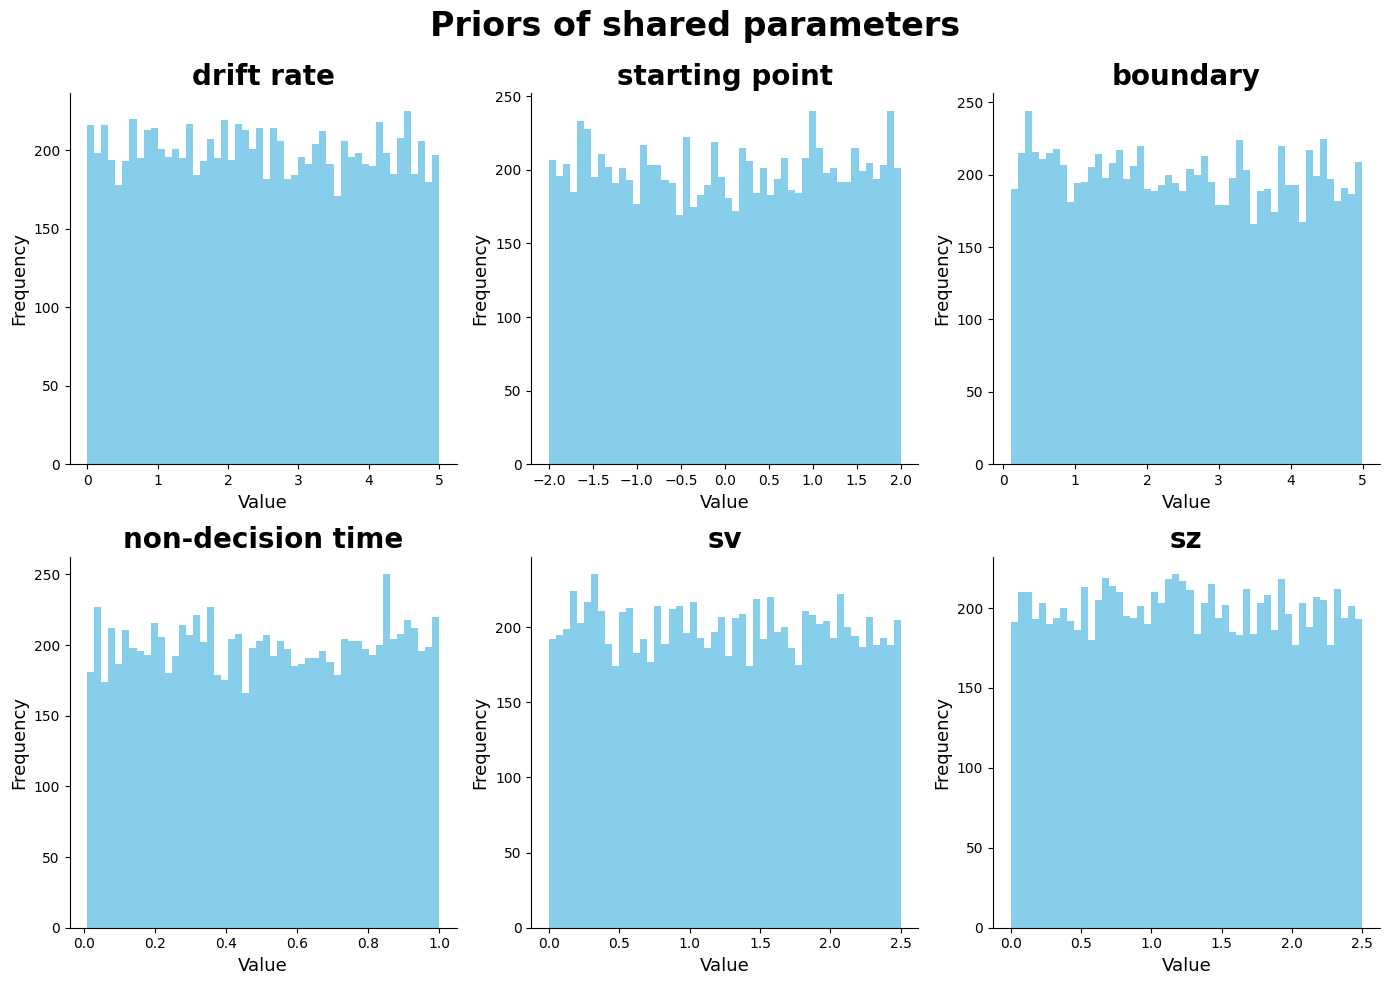

In [13]:
shared_param_labels = ["drift rate","starting point","boundary","non-decision time", "sv", "sz"]
fig, axes = plt.subplots(2, 3, figsize=(14, 10))

for i, ax in enumerate(axes.flatten()):
    ax.hist(plot_prior['prior_draws'][:, i], bins=50, color='skyblue')
    ax.set_xlabel("Value", fontsize=13)
    ax.set_ylabel("Frequency", fontsize=13)
    ax.set_title(shared_param_labels[i], fontsize=20, fontweight='bold')
    sns.despine()

fig.suptitle("Priors of shared parameters", fontsize=24, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.99])
#plt.savefig('vanilla_ddm_prior_shared.png')
plt.show()

### RT distributions

/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


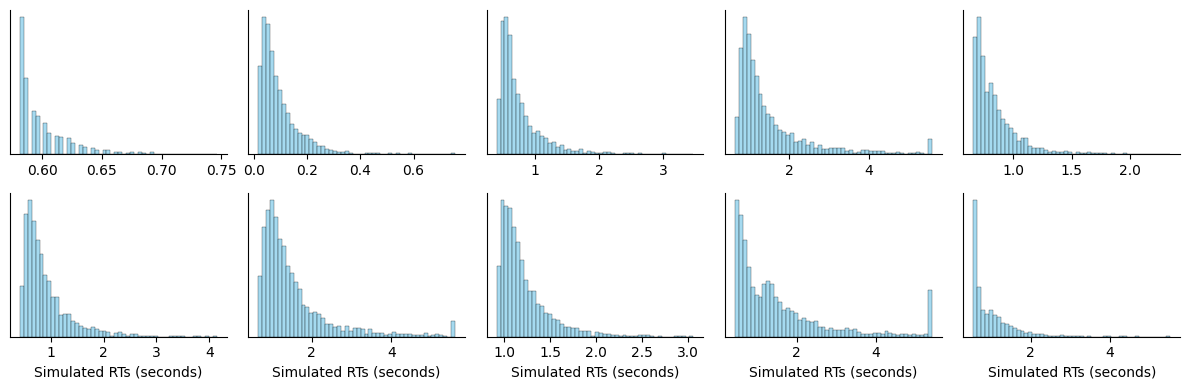

In [14]:
# if two distributions appear, this is because of extreme starting point value
example_sim = generative_model(batch_size=10)

f, axarr = plt.subplots(2, 5, figsize=(12, 4))
for i, ax in enumerate(axarr.flat):
    sns.histplot(example_sim["sim_data"][i, :, 0].flatten(), bins= 50, color="skyblue", alpha=0.75, ax=ax)
    sns.despine(ax=ax)
    ax.set_ylabel("")
    ax.set_yticks([])
    if i > 4:
        ax.set_xlabel("Simulated RTs (seconds)")
f.tight_layout()
plt.show()

## Setting up amortizer

In [15]:
""" 
summary_net: 
    learns the most informative summary stats from data 
inference_net: 
    from summary statistics to posterior distributions - joint posterior distribution
amortizer: 
    connects the two networks
"""


summary_net = bf.networks.SetTransformer(input_dim=3, summary_dim=32) # input_dim: rt, response, stimulus
inference_net = bf.networks.InvertibleNetwork(num_params=6) # v,z,a,ter,sv,sz
amortizer = bf.amortizers.AmortizedPosterior(inference_net, summary_net)

2026-06-16 10:31:04.314093: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2348] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 10.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2026-06-16 10:31:04.324000: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 180194 MB memory:  -> device: 0, name: NVIDIA B200, pci bus id: 0000:03:00.0, compute capability: 10.0


## Checkpoint path

In [16]:
checkpoint_path = f"/vsc-hard-mounts/leuven-data/343/vsc34314/DDM and clustered errors/6. Replication/2. Across-trial variability DDM/training_across_trial_variability_ddm"
if not os.path.exists(checkpoint_path):
    os.makedirs(checkpoint_path)

## Create configurator

In [17]:

"""
takes the raw outputs of the generative models and turns them into something with which neural networks can work
"""


def configurator(raw_dict, transform=True):
        """Configures the output of self.generator for a BayesFlow pipeline.

        1. Converts float64 to float32 (for TensorFlow)
        2. Scale the model parameters if tranform=True

        Parameters:
        -----------
        raw_dict  : dict
            A simulation dictionary as returned by ``bayesflow.simulation.GenerativeModel``
        transform : boolean, optional, default: True
            An indicator to standardize the parameter and log-transform reaction times. 

        Returns:
        --------
        input_dict : dict
            The simulation dictionary configured for ``bayesflow.amortizers.Amortizer``
        """

        # Convert to float32
        shared_parameters = raw_dict.get("prior_draws").astype(np.float32)

        # Convert list of condition indicators to a 2D array and add a
        # trailing dimension of 1, so shape becomes (batch_size, num_obs, 1)
        # We need this in order to easily concatenate the context (condition matrix) with the data
        context = np.array(raw_dict["sim_batchable_context"])[..., None]
        data = raw_dict.get("sim_data").astype(np.float32) # [batch_size, num_trials, 2], last dimension is (rt, resp)

        # Concatenate data (rt, resp) and context (condition matrix)
        summary_conditions = np.c_[data, context].astype(np.float32)

        # Make inference network aware of varying numbers of trials
        # We create a vector of shape (batch_size, 1) by repeating the sqrt(num_trials)
        # num_trials calculated as the length of the condition matrix
        vec_num_trials = context.shape[1] * np.ones((data.shape[0], 1))
        direct_conditions = np.sqrt(vec_num_trials).astype(np.float32)

        if transform:
            mean_shared, std_shared = return_mean_std_shared_parameters()
            
            # Log transform reaction times
            summary_conditions[:,:,0] = np.log(summary_conditions[:,:,0])
            
            out_dict = dict(
                parameters=(shared_parameters-mean_shared.astype(np.float32))/std_shared.astype(np.float32),
                summary_conditions=summary_conditions,
                direct_conditions=direct_conditions # see https://bayesflow.org/_examples/LCA_Model_Posterior_Estimation.html#defining-the-configurator
            )
            
        else:
            out_dict = dict(
                parameters=shared_parameters,
                summary_conditions=summary_conditions,
                direct_conditions=direct_conditions
            )

        return out_dict


In [18]:
raw_sample = generative_model(batch_size=1)
configured_output = configurator(raw_sample)

/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/dispatcher.py:697: NumbaPerformanceWarning: Grid size 75 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


In [19]:
raw_sample

{'prior_non_batchable_context': None,
 'prior_batchable_context': None,
 'prior_draws': array([[ 0.44518243, -0.51636369,  0.4280799 ,  0.54817503,  1.77480437,
          0.65950729]]),
 'sim_non_batchable_context': 2373,
 'sim_batchable_context': [array([ 0.04382348,  0.04537977, -0.34748356, ..., -0.47803601,
          0.08860922, -0.79853742])],
 'sim_data': array([[[0.59317505, 1.        ],
         [0.568175  , 0.        ],
         [0.64317507, 1.        ],
         ...,
         [0.558175  , 0.        ],
         [0.58317506, 1.        ],
         [0.60817504, 0.        ]]], dtype=float32)}

In [20]:
configured_output

{'parameters': array([[-0.9863125 ,  1.4509089 , -1.0425217 ,  0.45810056,  1.0076244 ,
         -1.133746  ]], dtype=float32),
 'summary_conditions': array([[[-0.52226573,  1.        ,  0.04382348],
         [-0.56532574,  0.        ,  0.04537977],
         [-0.44133833,  1.        , -0.34748355],
         ...,
         [-0.5830827 ,  0.        , -0.47803602],
         [-0.5392679 ,  1.        ,  0.08860922],
         [-0.49729252,  0.        , -0.79853743]]], dtype=float32),
 'direct_conditions': array([[48.713448]], dtype=float32)}

## Trainer setup

In [21]:
"""
Connect the networks (summary and inference) with the generative model 
"""


trainer = bf.trainers.Trainer(
    amortizer=amortizer,
    generative_model=generative_model,
    configurator=configurator,
    checkpoint_path=checkpoint_path)


INFO:root:Loaded loss history from /vsc-hard-mounts/leuven-data/343/vsc34314/DDM and clustered errors/6. Replication/2. Across-trial variability DDM/training_across_trial_variability_ddm/history_500.pkl.


INFO:root:Networks loaded from /vsc-hard-mounts/leuven-data/343/vsc34314/DDM and clustered errors/6. Replication/2. Across-trial variability DDM/training_across_trial_variability_ddm/ckpt-500


INFO:root:Performing a consistency check with provided components...


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/dispatcher.py:697: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


2026-06-16 10:31:06.757349: W external/local_xla/xla/stream_executor/gpu/asm_compiler.cc:225] Falling back to the CUDA driver for PTX compilation; ptxas does not support CC 10.0
2026-06-16 10:31:06.757381: W external/local_xla/xla/stream_executor/gpu/asm_compiler.cc:228] Used ptxas at ptxas
2026-06-16 10:31:06.757476: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-06-16 10:31:06.946038: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.


2026-06-16 10:31:07.052883: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.


2026-06-16 10:31:07.481122: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-06-16 10:31:07.481216: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-06-16 10:31:07.481342: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-06-16 10:31:07.481411: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-06-16 10:31:07.481438: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-06-16

## Training

In [22]:

"""
epochs:
    This parameter defines the total number of complete passes through the training dataset. 
    Each epoch consists of several iterations, where the model is exposed to different subsets of the data.

iterations_per_epoch: 
    This specifies the number of training iterations that occur in each epoch. 
    During each iteration, the model is updated based on a batch of new data.

batch_size: 
    This determines the number of simulations in each batch. 
    It’s the size of the data subset that the model will see and learn from in each iteration.

validation_sims:
    A number of simulations where the network sees a completely new batch of data in each iteration
    This step is about assessing the model’s performance on a separate set of data that it hasn’t been trained on.

"""

losses = trainer.train_online(epochs=500, 
                              iterations_per_epoch=1000,
                              batch_size=batch_size)



2026-06-16 10:31:07.690693: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-06-16 10:31:07.690730: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-06-16 10:31:07.690934: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-06-16 10:31:07.691298: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-06-16 10:31:07.691320: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-06-16

Training epoch 1:   0%|          | 0/1000 [00:00<?, ?it/s]

2026-06-16 10:31:16.702828: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-06-16 10:31:16.744801: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-06-16 10:31:16.851473: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-06-16 10:31:16.851561: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-06-16 10:31:16.852160: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-06-16

2026-06-16 10:31:17.078631: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.


2026-06-16 10:31:17.424873: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-06-16 10:31:17.442589: I external/local_xla/xla/service/service.cc:168] XLA service 0x14ef1e4364c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-16 10:31:17.442643: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA B200, Compute Capability 10.0
2026-06-16 10:31:17.446014: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-16 10:31:17.463948: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-06-16 10:31:17.483009: W external/local_xla/xla/service/gpu/nvptx_compiler.cc:408] Couldn't read CUDA driver version.
I0000 00:00:1781598677.494263 2181007 devi

...

Training epoch 496:   0%|          | 0/1000 [00:00<?, ?it/s]

Training epoch 497:   0%|          | 0/1000 [00:00<?, ?it/s]

Training epoch 498:   0%|          | 0/1000 [00:00<?, ?it/s]

Training epoch 499:   0%|          | 0/1000 [00:00<?, ?it/s]

Training epoch 500:   0%|          | 0/1000 [00:00<?, ?it/s]

## Inspecting loss

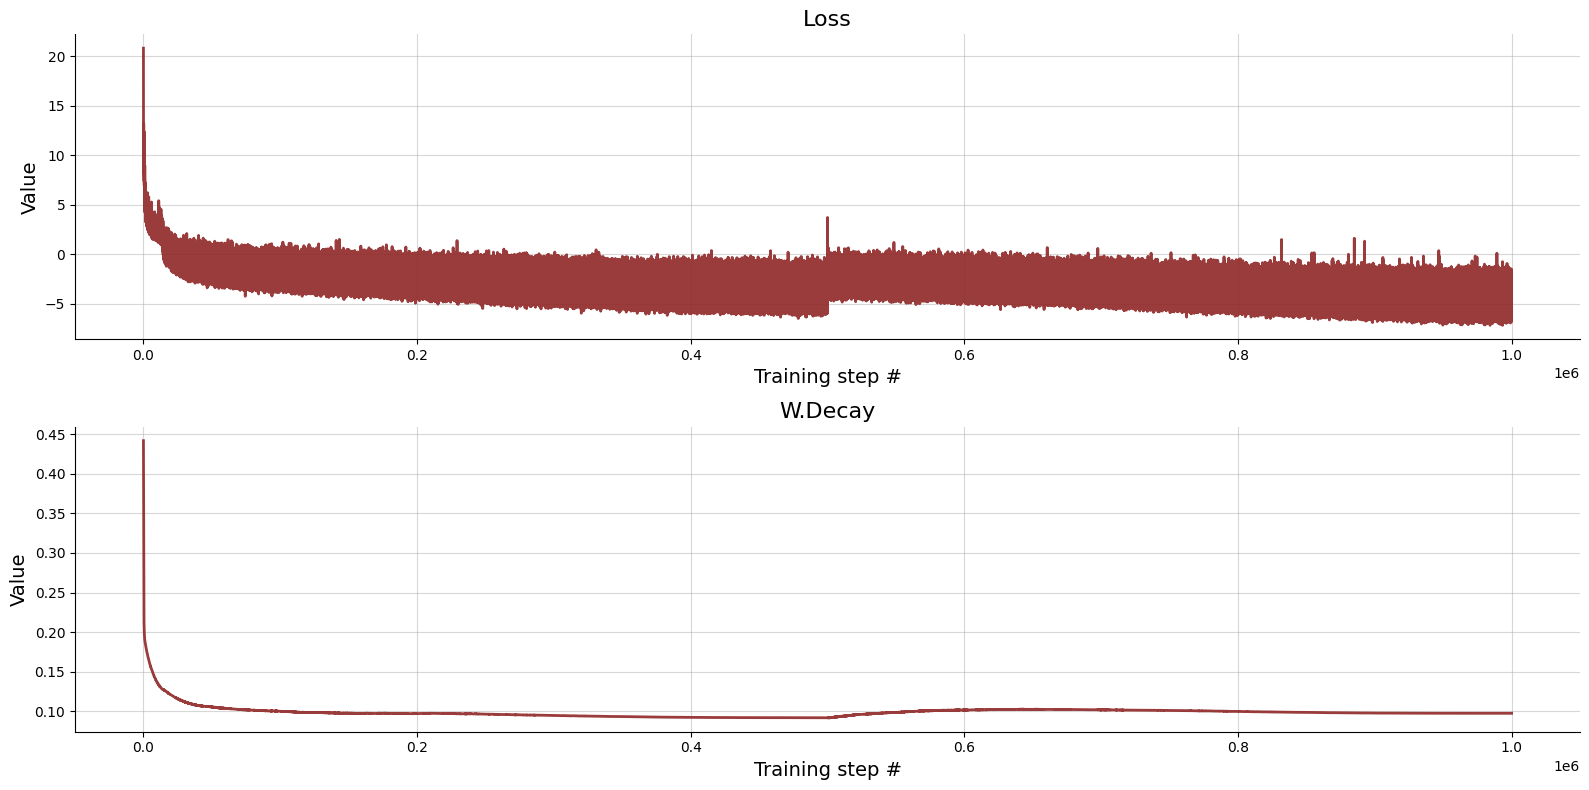

In [23]:
"""
A decreasing loss over time indicates that the model is learning effectively
"""

loss = bf.diagnostics.plot_losses(losses)
loss.savefig('Figures/across_trial_variability_ddm_losses.png') 